In [1]:
using ITensorMPS
using ITensors
using Plots
using DelimitedFiles
using Combinatorics
using Random


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; 

In [2]:
function entropy_von_neumann(psi::MPS)
  N = length(psi)
  s = siteinds(psi)
  entropies = []
  for b in 2:N-1
    orthogonalize!(psi, b)
    _,S = svd(psi[b], (siteind(psi, b), linkind(psi, b)))
    SvN = 0.0
    for n in 1:dim(S, 1)
      p = S[n,n]^2
      SvN -= p * log(p)
    end
    push!(entropies, SvN)
  end
  return entropies
end

function antiflatness(psi::MPS)
  N = length(psi)
  s = siteinds(psi)
  afs = []
  for b in 2:N-1
    orthogonalize!(psi, b)
    _,S = svd(psi[b], (siteind(psi, b), linkind(psi, b)))
    t1 = 0.0
    t2 = 0.0
    for n in 1:dim(S, 1)
      p = S[n,n]^2
      t1 += p^3
      t2 += p^2
    end
    push!(afs, t1 - t2^2)
  end
  return afs
end

# Only works for bond dimensions that
# are a power of 2
function nl_magic(psi::MPS)
    N = length(psi)
    s = siteinds(psi)
    mags = []
    for b in 2:N-1
        # Assuming MPS 'psi' and bond 'b'
        orthogonalize!(psi, b)
        U, S, V = svd(psi[b], (linkind(psi,b-1), linkind(psi, b)))
        
        # S contains the Schmidt coefficients (singular values)
        arg = 0.0
        for i in combinations(0:size(S, 1) - 1, 4)
            l1 = S[i[1]+1, i[1]+1]
            l2 = S[i[2]+1, i[2]+1]
            l3 = S[i[3]+1, i[3]+1]
            l4 = S[i[4]+1, i[4]+1]

            i5 = i[1] ⊻ i[2] ⊻ i[3] + 1
            l5 = S[i5, i5]

            i6 = i[1] ⊻ i[2] ⊻ i[4] + 1
            l6 = S[i6, i6]

            i7 = i[1] ⊻ i[3] ⊻ i[4] + 1
            l7 = S[i7, i7]

            i8 = i[2] ⊻ i[3] ⊻ i[4] + 1
            l8 = S[i8, i8]

            arg += l1 * l2 * l3 * l4 * l5 * l6 * l7 * l8
        end

        mag = -log2(arg)
        push!(mags, mag)
    end
    return mags
end

# function mc_sre(psi::MPS)
#   N = length(psi)
#   sites = siteinds(psi)
#   P_1 = ["Id", "X", "Y", "Z"]

#   # Thermalization
#   pstring = rand(P_1, N)
#   for i=1:50
#     s = rand(sites)
    
#   end
# end

nl_magic (generic function with 1 method)

# VQE Interacting Ground State

In [ ]:
N_s = 16
sites = siteinds("S=1/2", N_s)

h = 1.0
g = 0
J = 0.3


os = OpSum()
for j=1:N_s
    if j == N_s
        os -= J, "X", j, "X", 1
        os -= g, "Z", j, "Z", 1
    else
        os -= J, "X", j, "X", j+1
        os -= g, "Z", j, "Z", j+1
    end
    os -= h, "Z", j
end
H = MPO(os, sites)

psi0 = randomMPS(sites; linkdims=2^7)

nsweeps = 15
maxdim = [10,20,100,100,200]
cutoff = [1E-10]
noise = [1E-6]
weight = 50

energy0,psi0 = dmrg(H,psi0;nsweeps,maxdim,cutoff)

gs_af = antiflatness(psi0)

After sweep 1 energy=-16.36206046396905  maxlinkdim=10 maxerr=9.58E-04 time=0.014
After sweep 2 energy=-16.36207144752984  maxlinkdim=7 maxerr=9.11E-11 time=0.005
After sweep 3 energy=-16.362071447610557  maxlinkdim=7 maxerr=1.36E-11 time=0.007
After sweep 4 energy=-16.362071447610553  maxlinkdim=7 maxerr=1.36E-11 time=0.006
After sweep 5 energy=-16.36207144761054  maxlinkdim=7 maxerr=1.36E-11 time=0.005
After sweep 6 energy=-16.362071447610546  maxlinkdim=7 maxerr=1.36E-11 time=0.007
After sweep 7 energy=-16.362071447610532  maxlinkdim=7 maxerr=1.36E-11 time=0.005
After sweep 8 energy=-16.362071447610518  maxlinkdim=7 maxerr=1.36E-11 time=0.007
After sweep 9 energy=-16.36207144761058  maxlinkdim=7 maxerr=1.36E-11 time=0.007
After sweep 10 energy=-16.36207144761051  maxlinkdim=7 maxerr=1.36E-11 time=0.006
After sweep 11 energy=-16.362071447610553  maxlinkdim=7 maxerr=1.36E-11 time=0.005
After sweep 12 energy=-16.36207144761058  maxlinkdim=7 maxerr=1.36E-11 time=0.007
After sweep 13 ene

14-element Vector{Any}:
 0.010804058958386542
 0.011125904262029862
 0.011145804226191047
 0.011147185062420961
 0.011147286371386511
 0.011147294036308097
 0.01114729462694719
 0.011147294670332153
 0.011147294626795978
 0.011147294036447097
 0.011147286372119258
 0.011147185076960775
 0.011145804225014655
 0.01112590425728921

# Approximate Interacting Ground State

In [59]:
N_s = 16
h = 1.0
g = 0
J = 0.5

N_t = 500
tau = 1 / N_t

cutoff=1e-8
s = siteinds("S=1/2", N_s)
approx_vac_state = productMPS(s, "Up")

# Forward Evolution
for i in 1:N_t
    eps = exp(-(N_t - i))
    # eps = i/N_t
    for j in 1:N_s
        s1 = s[j]
        if j == N_s
            s2 = s[1]
        else
            s2 = s[j+1]
        end
        
        x1 = op("X", s1)
        x2 = op("X", s2)

        hxx = - J * x1 * x2

        Gj = exp(-1im * tau * eps *hxx)

        approx_vac_state = apply(Gj, approx_vac_state; cutoff)

        hz = - h * op("Z", s1)
        Gj = exp(-1im * tau * hz)
        approx_state = apply(Gj, approx_vac_state; cutoff)

        z1 = op("Z", s1)
        z2 = op("Z", s2)

        hzz = - g * z1 * z2
        Gj = exp(-1im * tau * eps *hzz)
        approx_vac_state = apply(Gj, approx_vac_state; cutoff)
    end
end

# # Backward Evolution
# for i in 1:250
#     for j in 1:N_s
#         s1 = s[j]
#         if j == N_s
#             s2 = s[1]
#         else
#             s2 = s[j+1]
#         end
        
#         x1 = op("X", s1)
#         x2 = op("X", s2)

#         hxx = -J * x1 * x2

#         Gj = exp(1im * tau * hxx)

#         approx_vac_state = apply(Gj, approx_vac_state; cutoff)

#         hz = - h * op("Z", s1)
#         Gj = exp(1im * tau * hz)
#         approx_vac_state = apply(Gj, approx_vac_state; cutoff)

#         z1 = op("Z", s1)
#         z2 = op("Z", s2)

#         hzz = -g * z1 * z2
#         Gj = exp(1im * tau * hzz)
#         approx_vac_state = apply(Gj, approx_vac_state; cutoff)
#     end
# end

In [60]:
# Make Time-Evolution Gates
tau = 0.05
N_t = 300
# g = 0.1

gates = ITensor[]
for j in 1:N_s
    s1 = s[j]
    if j == N_s
        s2 = s[1]
    else
        s2 = s[j+1]
    end
    
    x1 = op("X", s1)
    x2 = op("X", s2)

    hxx = -J * x1 * x2

    Gj = exp(-1im * tau * hxx/2)

    push!(gates, Gj)

    hz = - h * op("Z", s1)
    Gj = exp(-1im * tau * hz/2)
    push!(gates, Gj)

    z1 = op("Z", s1)
    z2 = op("Z", s2)

    hzz = -g * z1 * z2

    Gj = exp(-1im * tau * hzz/2)
    push!(gates, Gj)
end

# Include gates in reverse order too
# (N,N-1),(N-1,N-2),...
append!(gates, reverse(gates))

96-element Vector{ITensor}:
 ITensor ord=4
Dim 1: (dim=2|id=818|"S=1/2,Site,n=1")
Dim 2: (dim=2|id=874|"S=1/2,Site,n=2")
Dim 3: (dim=2|id=818|"S=1/2,Site,n=1")'
Dim 4: (dim=2|id=874|"S=1/2,Site,n=2")'
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2×2×2
[:, :, 1, 1] =
 0.9999218760172474 + 0.0im  0.0 + 0.0im
                0.0 + 0.0im  0.0 + 0.012499674481709789im

[:, :, 2, 1] =
                0.0 + 0.0im  0.0 + 0.012499674481709789im
 0.9999218760172474 + 0.0im  0.0 + 0.0im

[:, :, 1, 2] =
 0.0 + 0.0im                   0.9999218760172472 + 0.0im
 0.0 + 0.012499674481709789im                 0.0 + 0.0im

[:, :, 2, 2] =
 0.0 + 0.012499674481709789im                 0.0 + 0.0im
 0.0 + 0.0im                   0.9999218760172472 + 0.0im

 ITensor ord=2
Dim 1: (dim=2|id=818|"S=1/2,Site,n=1")'
Dim 2: (dim=2|id=818|"S=1/2,Site,n=1")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2
 0.9996875162757026 + 0.024997395914712332im  …                -0.0 + 0.0im
               -0.0 + 0.0

In [61]:
# Compute and print <Sz> at each time step
# then apply the gates to go to the next time
maxdim = 128
occs_vac = []
EEs_vac = []
afs_vac = []
# nl_mags_vac = []

ttotal = N_t * tau
state = deepcopy(approx_vac_state)
for t in 0:tau:ttotal
    # println("Pass 1")
    Sz = expect(state, "Z")
    occ = [(1 - Sz[n])/2 for n=1:N_s]
    push!(occs_vac, occ)

    EE = entropy_von_neumann(state)
    push!(EEs_vac, EE)

    af = antiflatness(state)
    push!(afs_vac, af)
    
    # nl_mag = nl_magic(state)
    # push!(nl_mags, nl_mag)
    
    t ≈ ttotal && break

    state = apply(gates, state; cutoff, maxdim)
    normalize!(state)
end

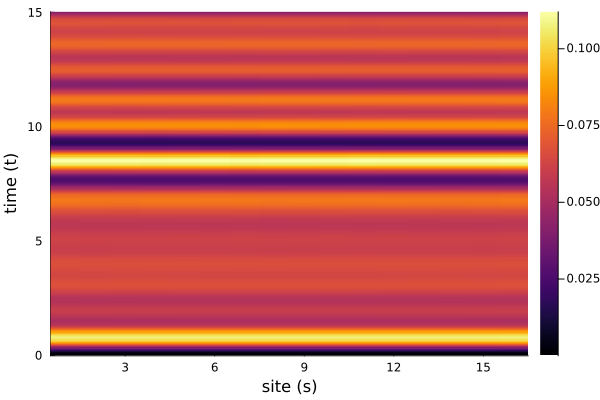

In [62]:
occs_mat = stack(occs_vac, dims=1)

heatmap(1:N_s, 0:tau:(N_t*tau), occs_mat, xlabel="site (s)", ylabel="time (t)")

# Free Initial State

In [63]:
function rz(theta::Float64, i::Int, psi::MPS, cutoff::Float64)
    s = siteinds(psi)
    z_i = op("Z", s[i])
    Op = exp(-1im/2 * theta * z_i)
    psi = apply(Op, psi; cutoff)
    return psi
end

function giv_op(theta::Float64, i::Int, j::Int, psi::MPS, cutoff::Float64)
    s = siteinds(psi)
    x_i = op("X", s[i])
    y_i = op("Y", s[i])
    x_j = op("X", s[j])
    y_j = op("Y", s[j])
    Op = x_i * y_j - x_j * y_i
    Op = exp(1im * theta / 2 * Op)
    psi = apply(Op, psi; cutoff)
    return psi
end

giv_op (generic function with 1 method)

In [64]:
betas_r = [-0.        ,  1.37444679,  2.74889357, -2.15984495, -0.78539816,
        0.58904862,  1.96349541, -2.94524311, -1.57079633, -0.19634954,
        1.17809725,  2.55254403, -2.35619449, -0.9817477 ,  0.39269908,
        1.76714587]
thetas_r = [-1.55248274, -1.57065844, -1.5707959 , -1.57079633, -1.5707959 ,
       -1.57065844, -1.55248581, -0.78556585, -0.06293259, -0.10815923,
       -0.25918264, -0.58569318, -1.0800756 , -1.44720622, -1.55743798]

betas_l = [-0.        , -1.37444679, -2.74889357,  2.15984495,  0.78539816,
       -0.58904862, -1.96349541,  2.94524311,  1.57079633,  0.19634954,
       -1.17809725, -2.55254403,  2.35619449,  0.9817477 , -0.39269908,
       -1.76714587]
thetas_l = [-0.04452199, -0.10805302, -0.25917978, -0.58569283, -1.0800755 ,
       -1.4472062 , -1.55743797, -1.57020121, -1.57078543, -1.57079624,
       -1.57079633, -1.57079633, -1.57079633, -1.57079624, -1.57078543]

15-element Vector{Float64}:
 -0.04452199
 -0.10805302
 -0.25917978
 -0.58569283
 -1.0800755
 -1.4472062
 -1.55743797
 -1.57020121
 -1.57078543
 -1.57079624
 -1.57079633
 -1.57079633
 -1.57079633
 -1.57079624
 -1.57078543

In [65]:
cutoff = 1E-8
maxdim = 40

# Make an array of 'site' indices
s = siteinds("S=1/2", N_s)

# State Preparation
n_kr = 7
n_kl = -n_kr
sigma = 3/2

free_init_state = productMPS(s, "Up")

for x in 1:N_s
    free_init_state = rz(betas_r[x], x, free_init_state, cutoff)
end
for x in 1:N_s-1
    y = N_s - x
    free_init_state = giv_op(thetas_r[x], y, y+1, free_init_state, cutoff)
end
sm = op("X", s[1]) - 1im * op("Y", s[1])
free_init_state = apply(sm, free_init_state; cutoff)
for x in 1:N_s-1
    y = N_s - x
    free_init_state = giv_op(-thetas_r[y], x, x+1, free_init_state, cutoff)
end
for x in 1:N_s
    free_init_state = rz(-betas_r[x], x, free_init_state, cutoff)
end

for x in 1:N_s
    free_init_state = rz(betas_l[x], x, free_init_state, cutoff)
end
for x in 1:N_s-1
    y = N_s - x
    free_init_state = giv_op(thetas_l[x], y, y+1, free_init_state, cutoff)
end
sm = op("X", s[1]) - 1im * op("Y", s[1])
free_init_state = apply(sm, free_init_state; cutoff)
for x in 1:N_s-1
    y = N_s - x
    free_init_state = giv_op(-thetas_l[y], x, x+1, free_init_state, cutoff)
end
for x in 1:N_s
    free_init_state = rz(-betas_l[x], x, free_init_state, cutoff)
end

[0.00017843481957513507, 0.015194190954209652, 0.21867351066304813, 0.5319070239844618, 0.21867351582662203, 0.015194191136870538, 0.0001784349442555122, 7.083268429575185e-7, 0.00017843507656367663, 0.01519418508083431, 0.2186735139238789, 0.5319070229589635, 0.21867351475376767, 0.015194185133098448, 0.0001784349800485474, 6.974369593515384e-7]


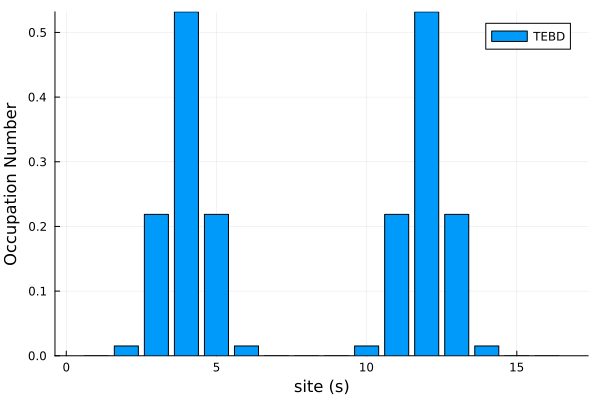

In [66]:
magz = expect(free_init_state, "Z")
occs = [(1 - magz[n])/2 for n=1:N_s]
println(occs)

sites = [n for n=1:N_s]
plot(bar(sites, occs; label="TEBD"), xlabel="site (s)", ylabel="Occupation Number")

# Interacting Initial State

In [67]:
N_t = 500
tau = 1 / N_t

init_state = deepcopy(free_init_state)

# Forward Evolution
for i in 1:N_t
    eps = exp(-(N_t - i))
    # eps = i/N_t
    for j in 1:N_s
        s1 = s[j]
        if j == N_s
            s2 = s[1]
        else
            s2 = s[j+1]
        end
        
        x1 = op("X", s1)
        x2 = op("X", s2)

        hxx = - J * x1 * x2

        Gj = exp(-1im * tau * eps *hxx)

        init_state = apply(Gj, init_state; cutoff)

        hz = - h * op("Z", s1)
        Gj = exp(-1im * tau * hz)
        init_state = apply(Gj, init_state; cutoff)

        z1 = op("Z", s1)
        z2 = op("Z", s2)

        hzz = - g * z1 * z2
        Gj = exp(-1im * tau * eps *hzz)
        init_state = apply(Gj, init_state; cutoff)
    end
end

# Backward Evolution
# for i in 1:250
#     for j in 1:N_s
#         s1 = s[j]
#         if j == N_s
#             s2 = s[1]
#         else
#             s2 = s[j+1]
#         end
        
#         x1 = op("X", s1)
#         x2 = op("X", s2)

#         hxx = -J * x1 * x2

#         Gj = exp(1im * tau * hxx)

#         init_state = apply(Gj, init_state; cutoff)

#         hz = - h * op("Z", s1)
#         Gj = exp(1im * tau * hz)
#         init_state = apply(Gj, init_state; cutoff)

#         z1 = op("Z", s1)
#         z2 = op("Z", s2)

#         hzz = -g * z1 * z2
#         Gj = exp(1im * tau * hzz)
#         init_state = apply(Gj, init_state; cutoff)
#     end
# end

[0.00017756490918324763, 0.015025056537634474, 0.21779613095301348, 0.5319050052275638, 0.2195550292906489, 0.015372565160022444, 0.00018850504991690942, 5.7582350276308425e-6, 0.0001885051371074975, 0.015372564612340711, 0.21955502711241337, 0.5319050039161073, 0.21779613508292922, 0.015025055989147051, 0.00017756446059041808, 3.5032060878847915e-6]


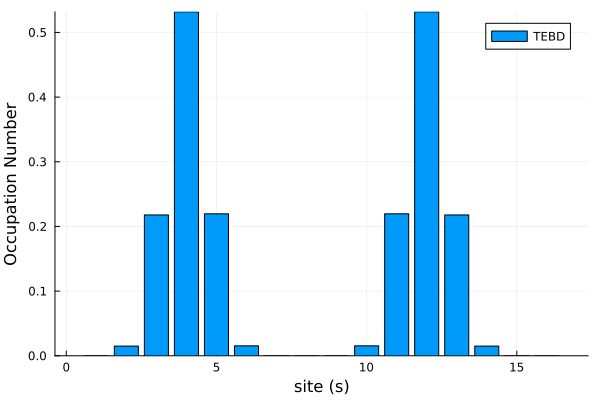

In [68]:
magz = expect(init_state, "Z")
occs = [(1 - magz[n])/2 for n=1:N_s]
println(occs)

sites = [n for n=1:N_s]
plot(bar(sites, occs; label="TEBD"), xlabel="site (s)", ylabel="Occupation Number")

# Time Evolution

In [69]:
# Make Time-Evolution Gates
tau = 0.05
N_t = 300
# g = 0.1

gates = ITensor[]
for j in 1:N_s
    s1 = s[j]
    if j == N_s
        s2 = s[1]
    else
        s2 = s[j+1]
    end
    
    x1 = op("X", s1)
    x2 = op("X", s2)

    hxx = -J * x1 * x2

    Gj = exp(-1im * tau * hxx/2)

    push!(gates, Gj)

    hz = - h * op("Z", s1)
    Gj = exp(-1im * tau * hz/2)
    push!(gates, Gj)

    z1 = op("Z", s1)
    z2 = op("Z", s2)

    hzz = -g * z1 * z2

    Gj = exp(-1im * tau * hzz/2)
    push!(gates, Gj)
end

# Include gates in reverse order too
# (N,N-1),(N-1,N-2),...
append!(gates, reverse(gates))

96-element Vector{ITensor}:
 ITensor ord=4
Dim 1: (dim=2|id=284|"S=1/2,Site,n=1")
Dim 2: (dim=2|id=945|"S=1/2,Site,n=2")
Dim 3: (dim=2|id=284|"S=1/2,Site,n=1")'
Dim 4: (dim=2|id=945|"S=1/2,Site,n=2")'
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2×2×2
[:, :, 1, 1] =
 0.9999218760172474 + 0.0im  0.0 + 0.0im
                0.0 + 0.0im  0.0 + 0.012499674481709789im

[:, :, 2, 1] =
                0.0 + 0.0im  0.0 + 0.012499674481709789im
 0.9999218760172474 + 0.0im  0.0 + 0.0im

[:, :, 1, 2] =
 0.0 + 0.0im                   0.9999218760172472 + 0.0im
 0.0 + 0.012499674481709789im                 0.0 + 0.0im

[:, :, 2, 2] =
 0.0 + 0.012499674481709789im                 0.0 + 0.0im
 0.0 + 0.0im                   0.9999218760172472 + 0.0im

 ITensor ord=2
Dim 1: (dim=2|id=284|"S=1/2,Site,n=1")'
Dim 2: (dim=2|id=284|"S=1/2,Site,n=1")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2
 0.9996875162757026 + 0.024997395914712332im  …                -0.0 + 0.0im
               -0.0 + 0.0

In [70]:
# Compute and print <Sz> at each time step
# then apply the gates to go to the next time
maxdim = 128
occs = []
EEs = []
afs = []
nl_mags = []
dims = []
ttotal = N_t * tau
state = deepcopy(init_state)
for t in 0:tau:ttotal
    # println("Pass 1")
    Sz = expect(state, "Z")
    occ = [(1 - Sz[n])/2 for n=1:N_s]
    push!(occs, occ)

    EE = entropy_von_neumann(state)
    push!(EEs, EE)

    af = antiflatness(state)
    push!(afs, af)
    
    nl_mag = nl_magic(state)
    push!(nl_mags, nl_mag)

    bond_dim = maxlinkdim(state)
    push!(dims, bond_dim)
    
    t ≈ ttotal && break

    state = apply(gates, state; cutoff, maxdim)
    normalize!(state)
end

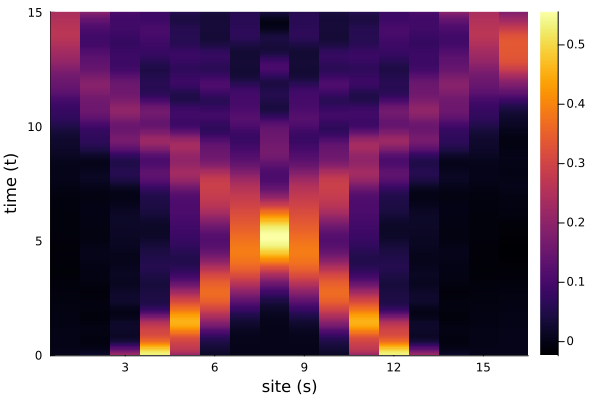

In [71]:
occs_mat = stack(occs, dims=1) - stack(occs_vac, dims=1)

heatmap(1:N_s, 0:tau:(N_t*tau), occs_mat, xlabel="site (s)", ylabel="time (t)")

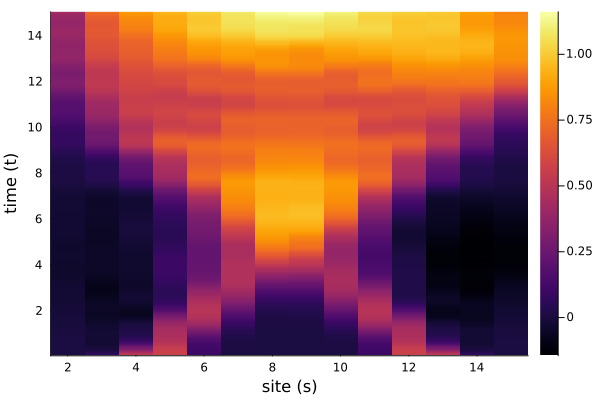

In [72]:
EEs_mat = stack(EEs, dims=1) - stack(EEs_vac, dims=1)
heatmap(2:N_s-1, tau:tau:(N_t*tau), EEs_mat[2:end,:], xlabel="site (s)", ylabel="time (t)")

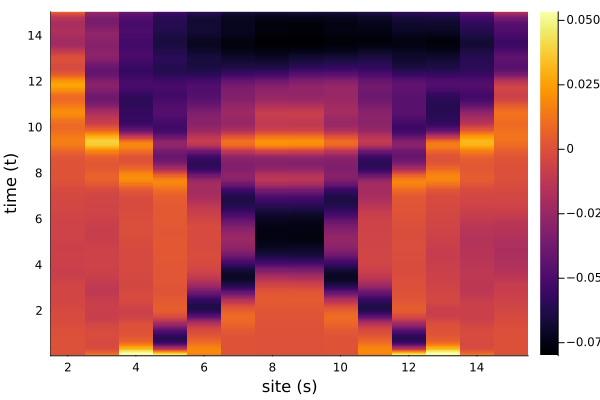

In [73]:
afs_mat = stack(afs, dims=1) - stack(afs_vac, dims=1)
# afs_mat = stack(afs, dims=1) .- stack(gs_af, dims=1)'
heatmap(2:N_s-1, tau:tau:(N_t*tau), afs_mat[2:end,:], xlabel="site (s)", ylabel="time (t)")

In [ ]:
title = "Data/"
title *= "ising-exact-occs-N_s" * string(N_s)
title *= "-J" * string(J)
title *= "-h" * string(h)
title *= "-g" * string(g)
title *= "-width" * string(sigma)
title *= "-dt" * string(tau) * ".txt"
writedlm(title, occs_mat)

In [ ]:
EEs_mat = stack(EEs, dims=1)
title = "Data/"
title *= "ising-exact-EEs-N_s" * string(N_s)
title *= "-J" * string(J)
title *= "-h" * string(h)
title *= "-g" * string(g)
title *= "-width" * string(sigma)
title *= "-dt" * string(tau) * ".txt"
writedlm(title, EEs_mat)